In [7]:
from ctypes import *
import time
from sys import path
import sys
from os import sep

if sys.platform.startswith("win"):
    dwf = cdll.dwf
    constants_path = "C:" + sep + "Program Files (x86)" + sep + "Digilent" + sep + "WaveFormsSDK" + sep + "samples" + sep + "py"
elif sys.platform.startswith("darwin"):
    dwf = cdll.LoadLibrary("/Library/Frameworks/dwf.framework/dwf")
    constants_path = "/Applications/WaveForms.app/Contents/Resources/SDK/samples/py"
else:
    dwf = cdll.LoadLibrary("libdwf.so")
    constants_path = "C:\\Program Files (x86)\\Digilent\\WaveFormsSDK\\samples\\py"

path.append(constants_path)
import dwfconstants as constants

In [8]:
device_count = c_int()
dwf.FDwfEnum(c_int(), byref(device_count))
hdwf=c_int()
dwf.FDwfDeviceOpen(c_int(0), byref(hdwf))

0

In [9]:
dwf.FDwfDeviceCloseAll()
filter_flags = c_int(constants.enumfilterType.value | constants.enumfilterUSB.value)
device_count = c_int()
dwf.FDwfEnum(filter_flags, byref(device_count))

hdwf = c_int()
dwf.FDwfDeviceOpen(c_int(-1), byref(hdwf))
if hdwf.value == 0:
    raise RuntimeError("Failed to open device.")
print(hdwf.value)

dwf.FDwfAnalogIOReset(hdwf)
dwf.FDwfAnalogIOChannelNodeSet(hdwf, c_int(0), c_int(1), c_double(3.0))
dwf.FDwfAnalogIOChannelNodeSet(hdwf, c_int(0), c_int(0), c_double(1))
dwf.FDwfAnalogIOEnableSet(hdwf, c_int(1))
time.sleep(0.5)

vpos = c_double()
dwf.FDwfAnalogIOStatus(hdwf)
dwf.FDwfAnalogIOChannelNodeStatus(hdwf, c_int(0), c_int(1), byref(vpos))
print(f"Power: +{vpos.value:.2f}V")

1
Power: +3.01V


In [10]:
DEVICE_ID=0x12
DEVICE_ADDR = 0x52
ENABLE_REG = 0x80
ATIME_REG = 0x81
CONTROL_REG = 0x8F
CDATAL_REG = 0x94
CDATAH_REG = 0x95
RDATAL_REG = 0x96
RDATAH_REG = 0x97
GDATAL_REG = 0x98
GDATAH_REG = 0x99
BDATAL_REG = 0x9A
BDATAH_REG = 0x9B
WTIME_REG = 0x83

def write_register(reg, value):
    iNak = c_int()
    rgTX = (c_ubyte * 2)(reg, value)
    dwf.FDwfDigitalI2cWrite(hdwf, c_int(DEVICE_ADDR), rgTX, c_int(2), byref(iNak))
    return iNak.value == 0

def read_register(reg):
    iNak = c_int()
    rgTX = (c_ubyte * 1)(reg)
    dwf.FDwfDigitalI2cWrite(hdwf, c_int(DEVICE_ADDR), rgTX, c_int(1), byref(iNak))
    if iNak.value == 0:
        rgRX = (c_ubyte * 1)()
        dwf.FDwfDigitalI2cRead(hdwf, c_int(DEVICE_ADDR), rgRX, c_int(1), byref(iNak))
        if iNak.value == 0:
            return rgRX[0]
    return None

dwf.FDwfDigitalI2cRateSet(hdwf, c_double(100e3))
dwf.FDwfDigitalI2cSclSet(hdwf, c_int(0))
dwf.FDwfDigitalI2cSdaSet(hdwf, c_int(1))
iNak = c_int()
dwf.FDwfDigitalI2cClear(hdwf, byref(iNak))

1

In [11]:
write_register(ENABLE_REG, 0x01)
time.sleep(0.01)
write_register(ENABLE_REG, 0x03)
write_register(ATIME_REG, 0xFF)
write_register(CONTROL_REG, 0x02)

def read_colors():
    time.sleep(0.1)
    
    clear_low = read_register(CDATAL_REG)
    clear_high = read_register(CDATAH_REG)
    red_low = read_register(RDATAL_REG)
    red_high = read_register(RDATAH_REG)
    green_low = read_register(GDATAL_REG)
    green_high = read_register(GDATAH_REG)
    blue_low = read_register(BDATAL_REG)
    blue_high = read_register(BDATAH_REG)
    
    if all(val is not None for val in [clear_low, clear_high, red_low, red_high, green_low, green_high, blue_low, blue_high]):
        clear = (clear_high << 8) | clear_low
        red = (red_high << 8) | red_low
        green = (green_high << 8) | green_low
        blue = (blue_high << 8) | blue_low
        return {'clear': clear, 'red': red, 'green': green, 'blue': blue}
    return None

In [48]:
# write_register(CONTROL_REG,0)
data={'clear': [], 'red': [], 'green': [], 'blue': []}
for i in range(100):
    # write_register(ATIME_REG,255-i)
    colors = read_colors()
    
    data['clear'].append(colors['clear'])
    data['red'].append(colors['red'])
    data['green'].append(colors['green'])
    data['blue'].append(colors['blue'])
    # print(f"Index {i}: {colors['clear']}, R: {colors['red']}, G: {colors['green']}, B: {colors['blue']}")


In [49]:
# print(arr)
import seaborn as sns
import pandas as pd
df = pd.DataFrame(data)
df.to_csv("3.0_nominal_data.csv", index=False)

print("Data saved to 3.0_nominal_data.csv")

Data saved to 3.0_nominal_data.csv


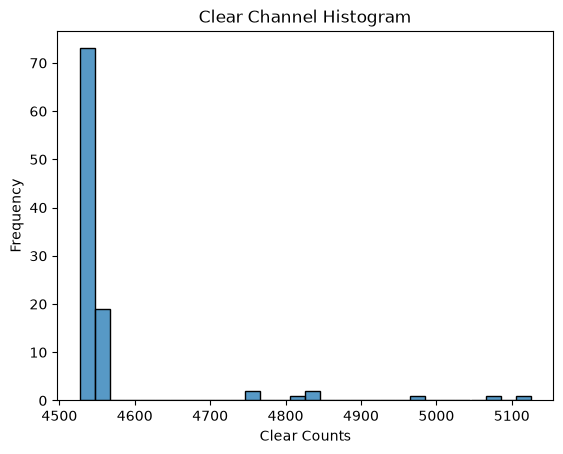

In [ ]:
import matplotlib.pyplot as plt
sns.histplot(data=df,x="clear", bins=30)
plt.title("Clear Channel Histogram")
plt.xlabel("Clear Counts")
plt.ylabel("Frequency")


# plt.plot(df["clear"])
# plt.xlabel("Sample Number")
# plt.ylabel("Clear Counts")
# plt.title("Clear Channel vs Sample Number")
plt.savefig("4.0_clear_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

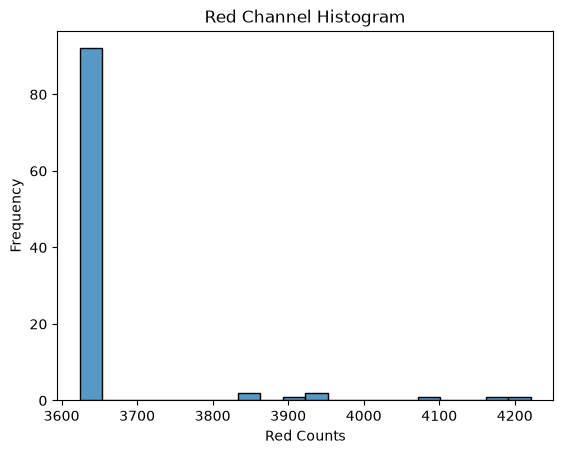

In [44]:
sns.histplot(data=df,x="red", bins=20)
plt.title("Red Channel Histogram")
plt.xlabel("Red Counts")
plt.ylabel("Frequency")

plt.savefig("4.0_red_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

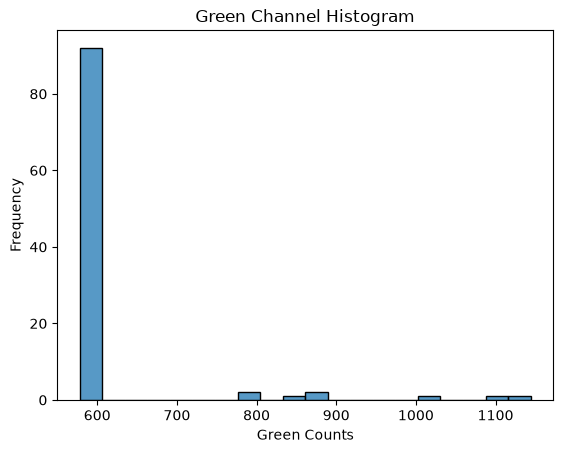

In [45]:
sns.histplot(data=df,x="green", bins=20)
plt.title("Green Channel Histogram")
plt.xlabel("Green Counts")
plt.ylabel("Frequency")

plt.savefig("4.0_green_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

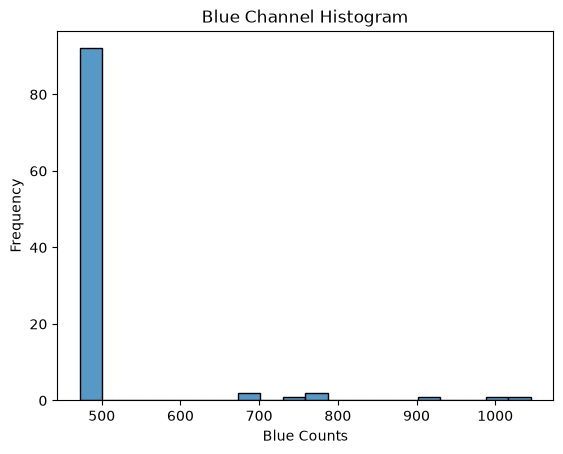

In [46]:
sns.histplot(data=df,x="blue", bins=20)
plt.title("Blue Channel Histogram")
plt.xlabel("Blue Counts")
plt.ylabel("Frequency")

plt.savefig("4.0_blue_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

1.0 verify sensor reading counts proportional to atime for all channels

In [32]:
import pandas as pd
import time

atime_regs = [0xFF, 0xF6, 0xD5, 0xC0]
atime_ms   = [2.4, 24, 103.2, 153.6]

results = {
    'ATIME_ms': [],
    'RedMean': [],
    'GreenMean': [],
    'BlueMean': [],
    'ClearMean': []
}

for i in range(len(atime_regs)):

    write_register(ATIME_REG, atime_regs[i])
    time.sleep(0.2)

    for j in range(100):

        colors = read_colors()

        if colors is None:
            continue

        results['ATIME_ms'].append(atime_ms[i])
        results['RedMean'].append(colors['red'])
        results['GreenMean'].append(colors['green'])
        results['BlueMean'].append(colors['blue'])
        results['ClearMean'].append(colors['clear'])

# Convert dictionary to DataFrame
df = pd.DataFrame(results)



# Save to CSV
df.to_csv("1.0_atime_sweep.csv", index=False)

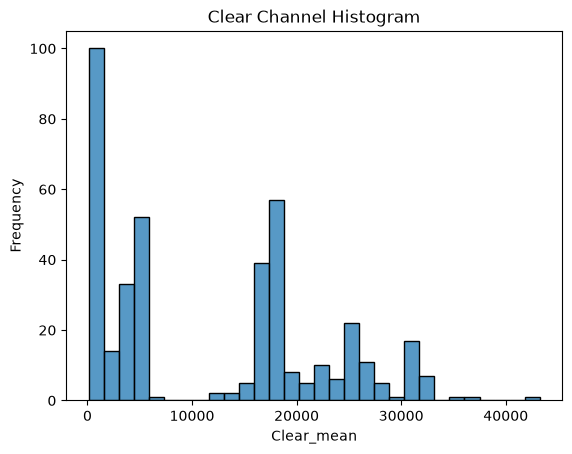

In [33]:
import matplotlib.pyplot as plt
sns.histplot(df["ClearMean"], bins=30)
plt.title("Clear Channel Histogram")
plt.xlabel("Clear_mean")
plt.ylabel("Frequency")


# plt.plot(df["clear"])
# plt.xlabel("Sample Number")
# plt.ylabel("Clear Counts")
# plt.title("Clear Channel vs Sample Number")
plt.savefig("1.0_clear_mean_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

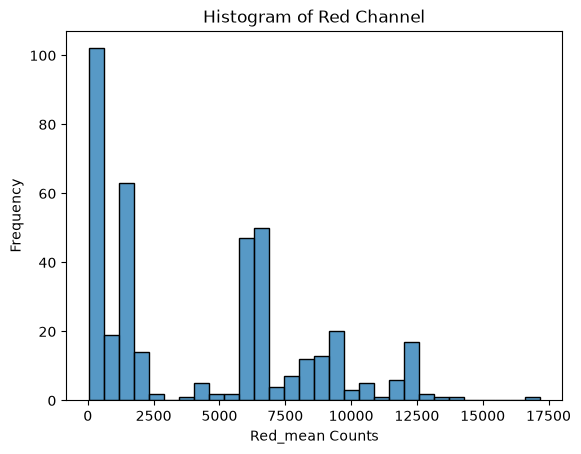

In [35]:

sns.histplot(df["RedMean"], bins=30)
plt.xlabel("Red_mean Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Red Channel")

plt.savefig("1.0_red_mean_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

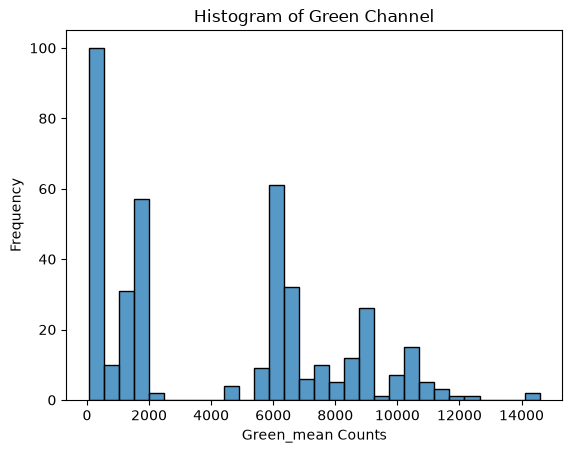

In [36]:
sns.histplot(df["GreenMean"], bins=30)
plt.xlabel("Green_mean Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Green Channel")

plt.savefig("1.0_green_mean_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

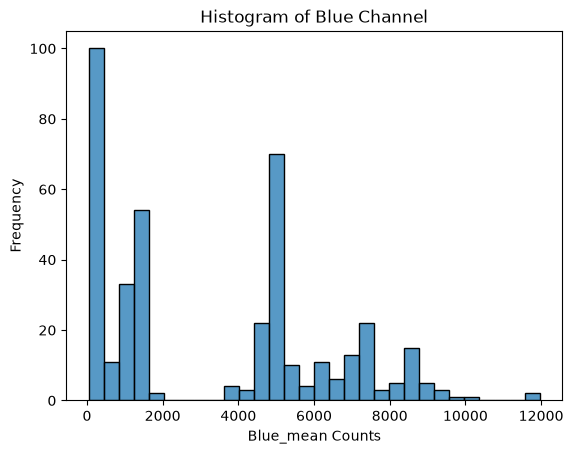

In [37]:
sns.histplot(df["BlueMean"], bins=30)
plt.xlabel("Blue_mean Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Blue Channel")

plt.savefig("1.0_blue_mean_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

1.1 verify sensor reading counts proportional to gain for all channels

In [12]:
import numpy as np
import pandas as pd
import time

gain_regs = [0x00, 0x01, 0x02, 0x03]
gain_values = [1, 4, 16, 60]

results = {
    'Gain': [],
    'RedMean': [],
    'GreenMean': [],
    'BlueMean': [],
    'ClearMean': []
}

# Keep ATIME fixed
write_register(ATIME_REG, 0xFF)

for i in range(len(gain_regs)):

    # Set Gain
    write_register(CONTROL_REG, gain_regs[i])

    # Allow sensor to settle
    time.sleep(0.2)

    red = []
    green = []
    blue = []
    clear = []

    # Collect 100 samples
    for j in range(100):

        colors = read_colors()

        if colors is None:
            continue

        red.append(colors['red'])
        green.append(colors['green'])
        blue.append(colors['blue'])
        clear.append(colors['clear'])

    # Store Mean Values
    results['Gain'].append(gain_values[i])
    results['RedMean'].append(np.mean(red))
    results['GreenMean'].append(np.mean(green))
    results['BlueMean'].append(np.mean(blue))
    results['ClearMean'].append(np.mean(clear))

    print(f"Gain = {gain_values[i]}x")
    print(f"Red Mean   = {np.mean(red):.2f}")
    print(f"Green Mean = {np.mean(green):.2f}")
    print(f"Blue Mean  = {np.mean(blue):.2f}")
    print(f"Clear Mean = {np.mean(clear):.2f}")
    print()

df = pd.DataFrame(results)



# Save to CSV
df.to_csv("1.1_Gain_sweep.csv", index=False)

Gain = 1x
Red Mean   = 6.70
Green Mean = 7.56
Blue Mean  = 6.08
Clear Mean = 21.08

Gain = 4x
Red Mean   = 30.07
Green Mean = 33.83
Blue Mean  = 27.24
Clear Mean = 94.23

Gain = 16x
Red Mean   = 116.60
Green Mean = 129.48
Blue Mean  = 106.51
Clear Mean = 363.07

Gain = 60x
Red Mean   = 461.45
Green Mean = 454.43
Blue Mean  = 375.53
Clear Mean = 991.66



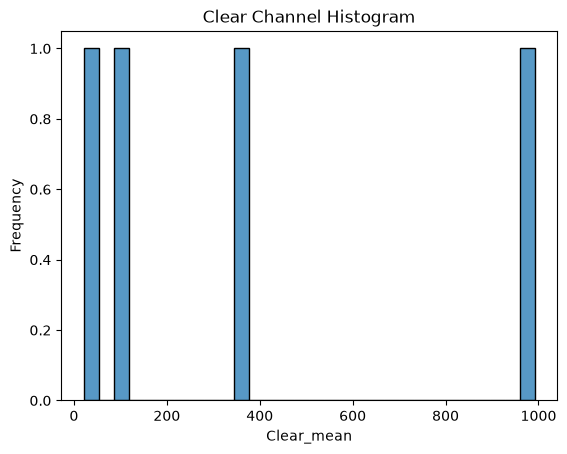

In [14]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
sns.histplot(df["ClearMean"], bins=30)
plt.title("Clear Channel Histogram")
plt.xlabel("Clear_mean")
plt.ylabel("Frequency")

plt.savefig("1.1_clear_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

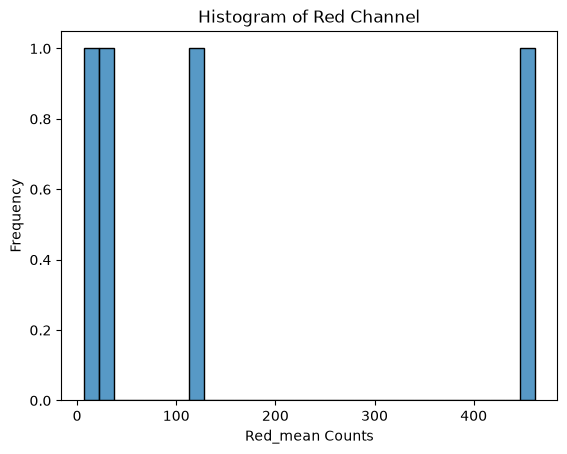

In [15]:

sns.histplot(df["RedMean"], bins=30)
plt.xlabel("Red_mean Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Red Channel")

plt.savefig("1.1_red_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

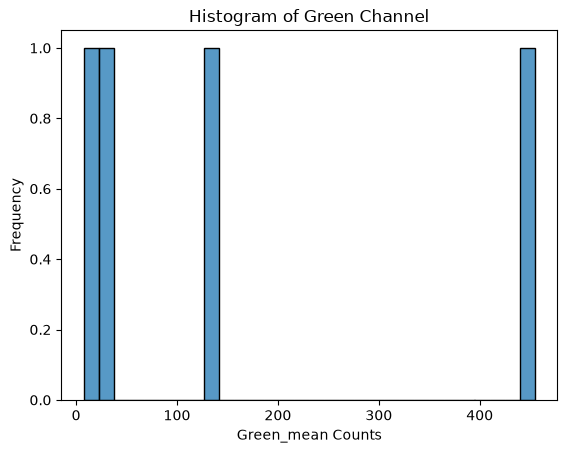

In [16]:
sns.histplot(df["GreenMean"], bins=30)
plt.xlabel("Green_mean Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Green Channel")

plt.savefig("1.1_green_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

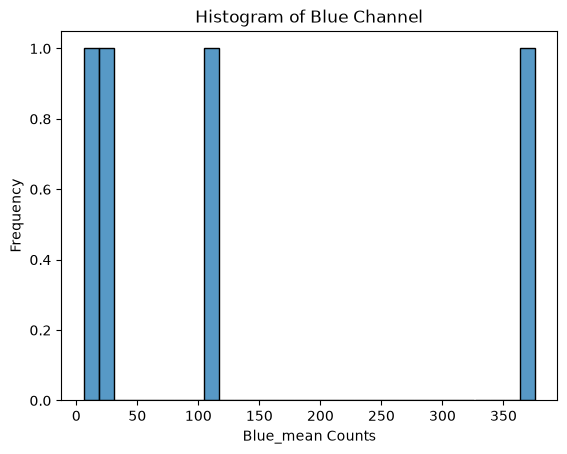

In [17]:
sns.histplot(df["BlueMean"], bins=30)
plt.xlabel("Blue_mean Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Blue Channel")

plt.savefig("1.1_blue_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

2.0 characterize the affect of wait time on sensor reading counts

In [18]:
wtime_regs = [0xFF, 0xF6, 0xD5, 0xC0]
wtime_ms   = [2.4, 24, 103.2, 153.6]
results = {
    'WTIME_ms': [],
    'RedMean': [],
    'GreenMean': [],
    'BlueMean': [],
    'ClearMean': []
}

for i in range(len(wtime_regs)):

    write_register(WTIME_REG, wtime_regs[i])

    time.sleep(0.2)

    red = []
    green = []
    blue = []
    clear = []

    for j in range(100):

        colors = read_colors()

        if colors is None:
            continue

        red.append(colors['red'])
        green.append(colors['green'])
        blue.append(colors['blue'])
        clear.append(colors['clear'])

    results['WTIME_ms'].append(wtime_ms[i])
    results['RedMean'].append(np.mean(red))
    results['GreenMean'].append(np.mean(green))
    results['BlueMean'].append(np.mean(blue))
    results['ClearMean'].append(np.mean(clear))

df = pd.DataFrame(results)



# Save to CSV
df.to_csv("2.0_Wtime_sweep.csv", index=False)

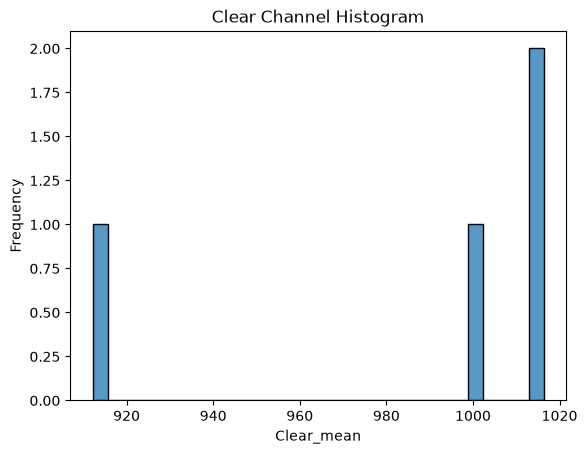

In [ ]:
import matplotlib.pyplot as plt
sns.histplot(df["ClearMean"], bins=30)
plt.title("Clear Channel Histogram")
plt.xlabel("Clear_mean")
plt.ylabel("Frequency")

plt.savefig("2.0_clear_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

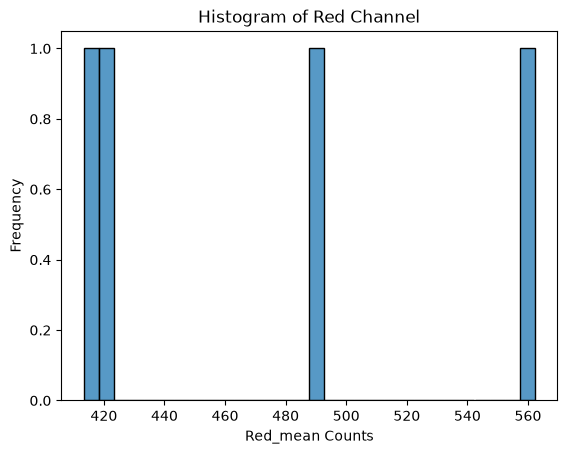

In [20]:

sns.histplot(df["RedMean"], bins=30)
plt.xlabel("Red_mean Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Red Channel")

plt.savefig("2.0_red_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

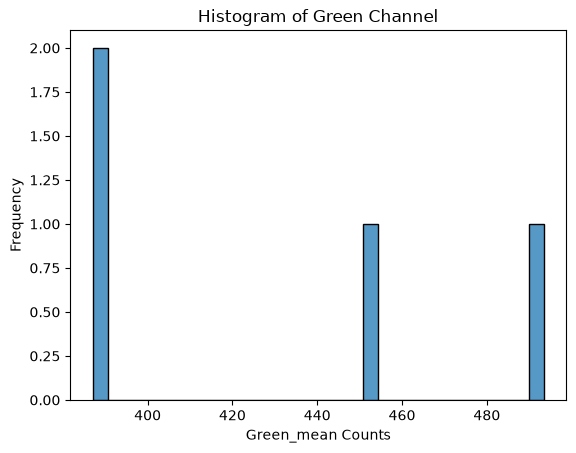

In [21]:
sns.histplot(df["GreenMean"], bins=30)
plt.xlabel("Green_mean Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Green Channel")

plt.savefig("2.0_green_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

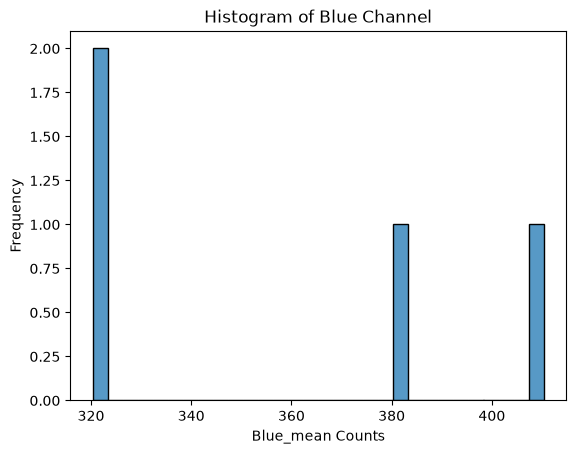

In [22]:
sns.histplot(df["BlueMean"], bins=30)
plt.xlabel("Blue_mean Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Blue Channel")

plt.savefig("2.0_blue_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

2.1 verify sensor reading counts [jitter] vs gain and vs atime

jitter VS gain

In [23]:
import numpy as np
import pandas as pd
import time

gain_regs = [0x00, 0x01, 0x02, 0x03]
gain_values = [1, 4, 16, 60]

results = {
    'Gain': [],
    'RedJitter': [],
    'GreenJitter': [],
    'BlueJitter': [],
    'ClearJitter': []
}

# Keep ATIME fixed
write_register(ATIME_REG, 0xFF)

for i in range(len(gain_regs)):

    write_register(CONTROL_REG, gain_regs[i])

    time.sleep(0.2)

    red = []
    green = []
    blue = []
    clear = []

    for j in range(100):

        colors = read_colors()

        if colors is None:
            continue

        red.append(colors['red'])
        green.append(colors['green'])
        blue.append(colors['blue'])
        clear.append(colors['clear'])

    results['Gain'].append(gain_values[i])
    results['RedJitter'].append(np.std(red))
    results['GreenJitter'].append(np.std(green))
    results['BlueJitter'].append(np.std(blue))
    results['ClearJitter'].append(np.std(clear))

df = pd.DataFrame(results)



# Save to CSV
df.to_csv("2.1_jitter vs gain DATA.csv", index=False)

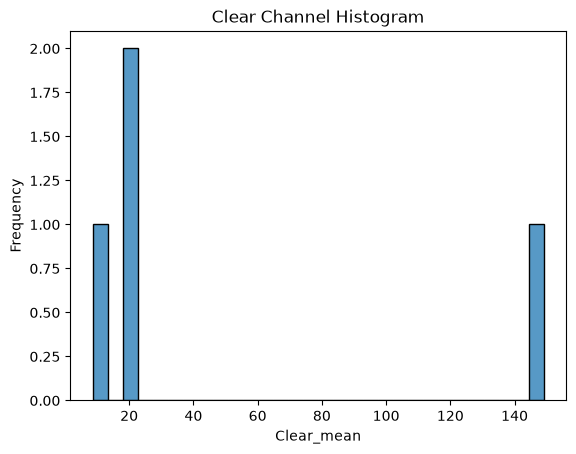

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
sns.histplot(df["ClearJitter"], bins=30)
plt.title("Clear Channel Histogram")
plt.xlabel("Clear_mean")
plt.ylabel("Frequency")

plt.savefig("2.1_jitter vs gain_clear_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

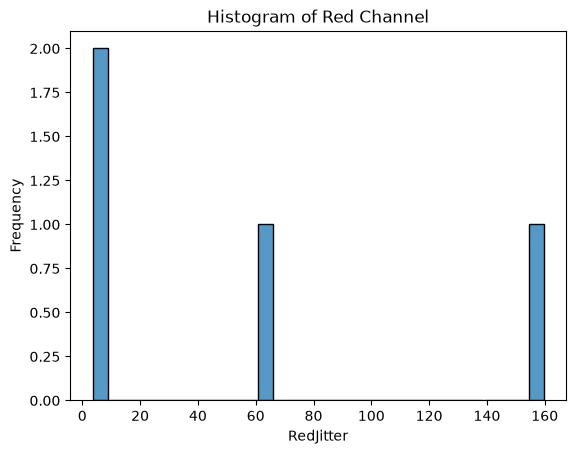

In [28]:
sns.histplot(df["RedJitter"], bins=30)
plt.xlabel("RedJitter")
plt.ylabel("Frequency")
plt.title("Histogram of Red Channel")

plt.savefig("2.1_jitter VS gain_Red_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

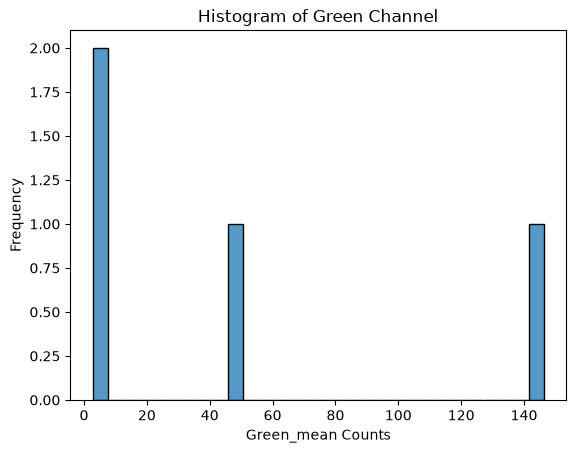

In [29]:
sns.histplot(df["GreenJitter"], bins=30)
plt.xlabel("Green_mean Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Green Channel")

plt.savefig("2.1_jitter VS gain_green_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

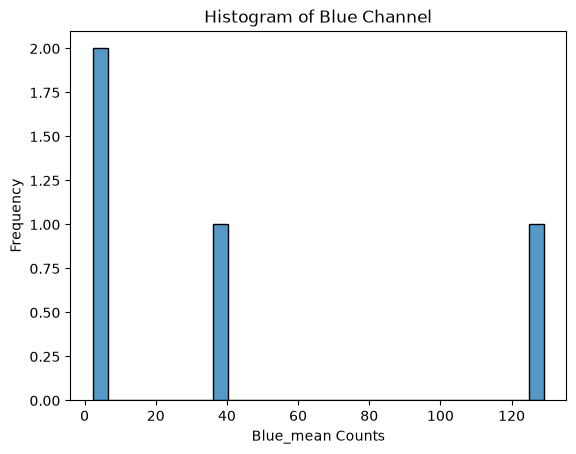

In [30]:
sns.histplot(df["BlueJitter"], bins=30)
plt.xlabel("Blue_mean Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Blue Channel")

plt.savefig("2.1_jitter VS gain_blue_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

jitter VS atime

In [32]:
results = {
    'ATIME_ms': [],
    'RedJitter': [],
    'GreenJitter': [],
    'BlueJitter': [],
    'ClearJitter': []
}
atime_regs = [0xFF, 0xF6, 0xD5, 0xC0]
atime_ms   = [2.4, 24, 103.2, 153.6]

# Keep Gain fixed
write_register(CONTROL_REG, 0x02)

for i in range(len(atime_regs)):

    write_register(ATIME_REG, atime_regs[i])

    time.sleep(0.2)

    red = []
    green = []
    blue = []
    clear = []

    for j in range(100):

        colors = read_colors()

        if colors is None:
            continue

        red.append(colors['red'])
        green.append(colors['green'])
        blue.append(colors['blue'])
        clear.append(colors['clear'])

    results['ATIME_ms'].append(atime_ms[i])
    results['RedJitter'].append(np.std(red))
    results['GreenJitter'].append(np.std(green))
    results['BlueJitter'].append(np.std(blue))
    results['ClearJitter'].append(np.std(clear))

df = pd.DataFrame(results)



# Save to CSV
df.to_csv("2.1_jitter vs atime DATA.csv", index=False)

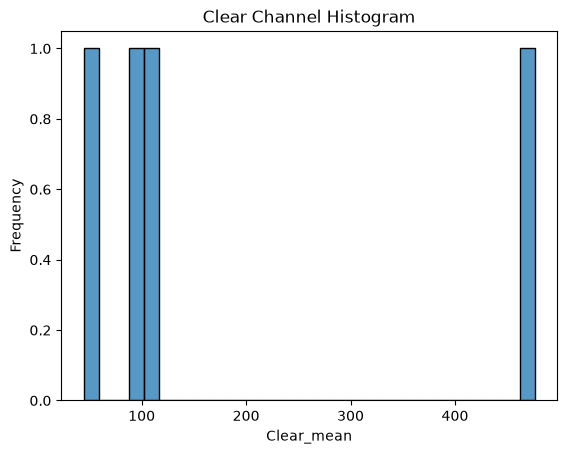

In [34]:
import matplotlib.pyplot as plt
sns.histplot(df["ClearJitter"], bins=30)
plt.title("Clear Channel Histogram")
plt.xlabel("Clear_mean")
plt.ylabel("Frequency")

plt.savefig("2.1_jitter VS atime_clear_histogram.png", dpi=300, bbox_inches="tight")

plt.show()

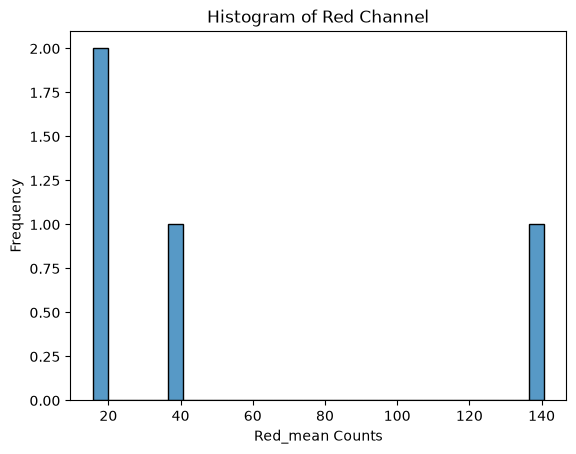

In [35]:
sns.histplot(df["RedJitter"], bins=30)
plt.xlabel("Red_mean Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Red Channel")

plt.savefig("2.1_jitter VS atime_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

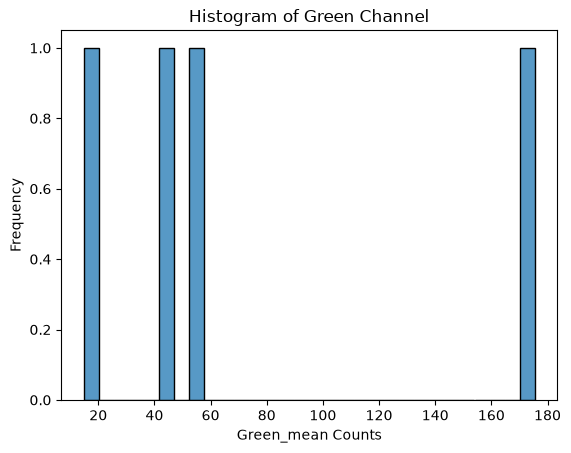

In [36]:
sns.histplot(df["GreenJitter"], bins=30)
plt.xlabel("Green_mean Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Green Channel")

plt.savefig("2.1_jitter VS gain_green_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

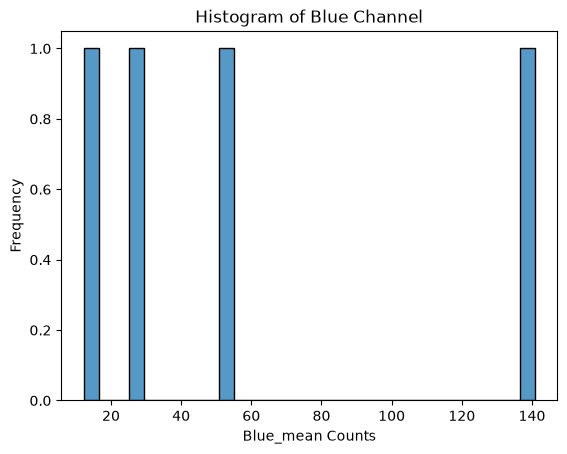

In [37]:
sns.histplot(df["BlueJitter"], bins=30)
plt.xlabel("Blue_mean Counts")
plt.ylabel("Frequency")
plt.title("Histogram of Blue Channel")

plt.savefig("2.1_jitter VS gain_blue_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

6.0 determine the min and max I2C clock frequency for reliable communication

In [39]:
import time
import pandas as pd

results = {
    'Frequency_Hz': [],
    'Success': [],
    'Failure': []
}

# Sweep from 1 kHz to 1 MHz in 10 kHz steps
for freq in range(1000, 1000001, 10000):

    dwf.FDwfDigitalI2cRateSet(
        hdwf,
        c_double(freq)
    )

    time.sleep(0.1)

    success = 0
    failure = 0

    for i in range(10):

        colors = read_colors()

        if colors is None:
            failure += 1
        else:
            success += 1

    results['Frequency_Hz'].append(freq)
    results['Success'].append(success)
    results['Failure'].append(failure)

    print(f"{freq:7d} Hz   Success = {success:3d}   Failure = {failure:3d}")
df = pd.DataFrame(results)



# Save to CSV
df.to_csv("6.0_I2C_DATA.csv", index=False)
    

   1000 Hz   Success =  10   Failure =   0
  11000 Hz   Success =  10   Failure =   0
  21000 Hz   Success =  10   Failure =   0
  31000 Hz   Success =  10   Failure =   0
  41000 Hz   Success =  10   Failure =   0
  51000 Hz   Success =  10   Failure =   0
  61000 Hz   Success =  10   Failure =   0
  71000 Hz   Success =  10   Failure =   0
  81000 Hz   Success =  10   Failure =   0
  91000 Hz   Success =  10   Failure =   0
 101000 Hz   Success =  10   Failure =   0
 111000 Hz   Success =  10   Failure =   0
 121000 Hz   Success =  10   Failure =   0
 131000 Hz   Success =  10   Failure =   0
 141000 Hz   Success =  10   Failure =   0
 151000 Hz   Success =  10   Failure =   0
 161000 Hz   Success =  10   Failure =   0
 171000 Hz   Success =  10   Failure =   0
 181000 Hz   Success =  10   Failure =   0
 191000 Hz   Success =  10   Failure =   0
 201000 Hz   Success =  10   Failure =   0
 211000 Hz   Success =  10   Failure =   0
 221000 Hz   Success =  10   Failure =   0
 231000 Hz 

4.0 verify colour sensor functionality (example: red colour light should output higher counts in red channel counts)

In [42]:
# write_register(CONTROL_REG,0)
data={'clear': [], 'red': [], 'green': [], 'blue': []}
for i in range(100):
    # write_register(ATIME_REG,255-i)
    colors = read_colors()
    
    data['clear'].append(colors['clear'])
    data['red'].append(colors['red'])
    data['green'].append(colors['green'])
    data['blue'].append(colors['blue'])
    # print(f"Index {i}: {colors['clear']}, R: {colors['red']}, G: {colors['green']}, B: {colors['blue']}")
import seaborn as sns
import pandas as pd
df = pd.DataFrame(data)
df.to_csv("4.0_RED_data.csv", index=False)

print("Data saved to 4.0_nominal_data.csv")

Data saved to 4.0_nominal_data.csv


7.0 – Interrupt Trigger vs Gain

In [ ]:
STATUS_REG = 0x93

AILTL_REG = 0x84
AILTH_REG = 0x85

AIHTL_REG = 0x86
AIHTH_REG = 0x87

import pandas as pd
import time

gain_regs = [0x00,0x01,0x02,0x03]
gain_values = [1,4,16,60]

results = {
    'Gain':[],
    'ClearCount':[],
    'InterruptStatus':[]
}

# Enable Interrupt
write_register(ENABLE_REG,0x13)

# ATIME = 24 ms
write_register(ATIME_REG,0xF6)

# Low Threshold = 0
write_register(AILTL_REG,0x00)
write_register(AILTH_REG,0x00)

# High Threshold = 2000 (0x07D0)
write_register(AIHTL_REG,0xD0)
write_register(AIHTH_REG,0x07)

for i in range(len(gain_regs)):

    write_register(CONTROL_REG,gain_regs[i])

    time.sleep(0.2)

    colors = read_colors()

    status = read_register(STATUS_REG)

    interrupt = (status & 0x10)>>4

    results['Gain'].append(gain_values[i])
    results['ClearCount'].append(colors['clear'])
    results['InterruptStatus'].append(interrupt)

    print("Gain =",gain_values[i],"x")
    print("Clear =",colors['clear'])
    print("Interrupt =",interrupt)

    # Clear Interrupt
    tx=(c_ubyte*1)(0x66)
    iNak=c_int()

    dwf.FDwfDigitalI2cWrite(
        hdwf,
        c_int(DEVICE_ADDR),
        tx,
        c_int(1),
        byref(iNak)
    )

    time.sleep(0.1)

write_register(ENABLE_REG,0x03)

In [ ]:
df=pd.DataFrame(results)

df.to_csv("interrupt_vs_gain.csv",index=False)